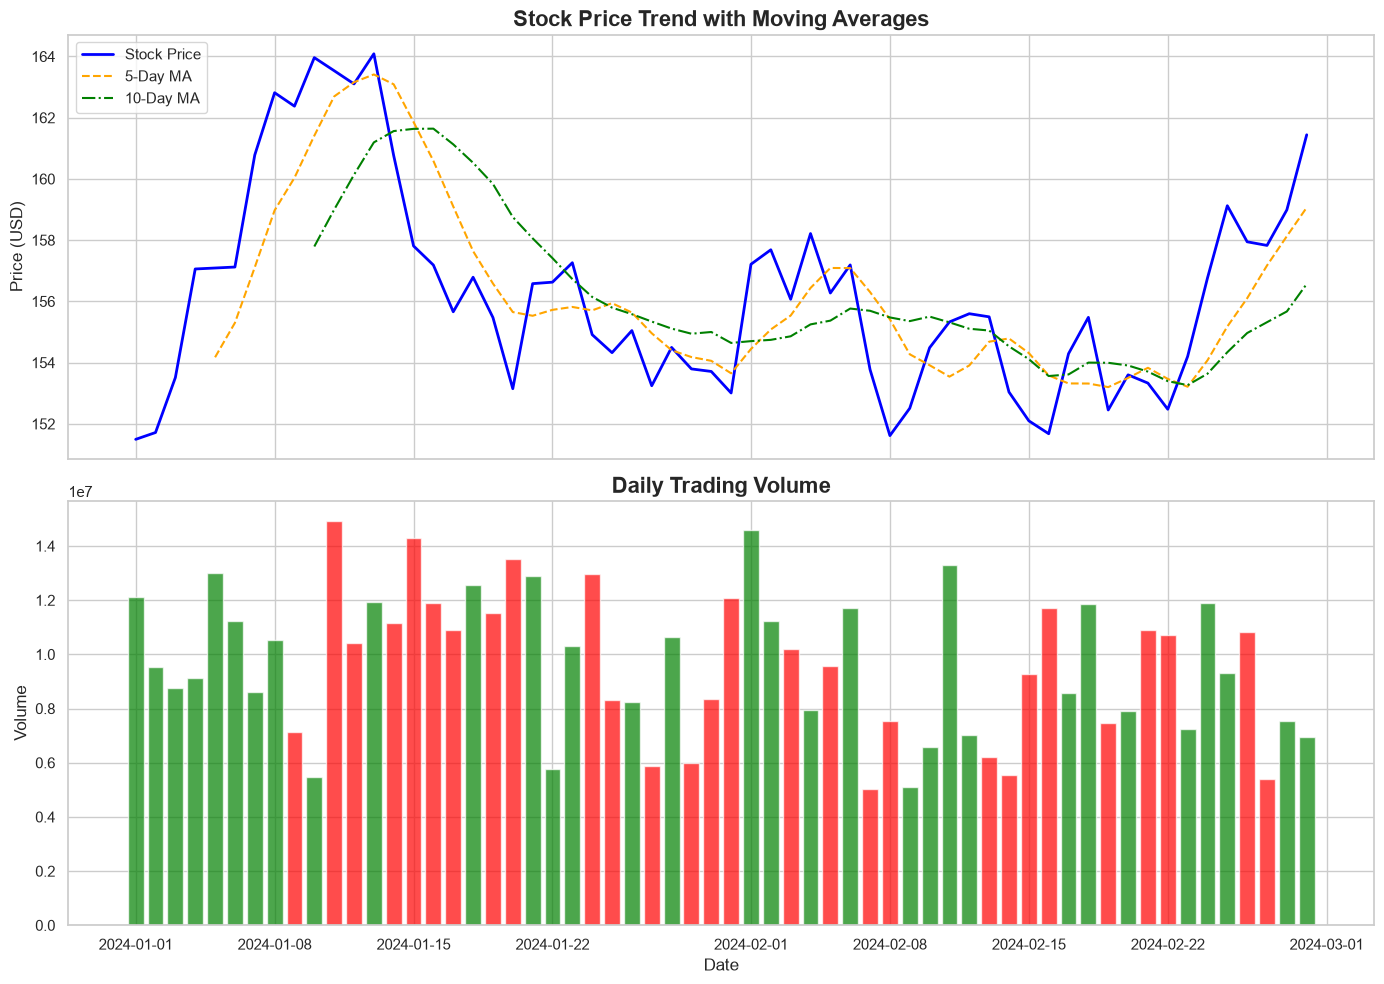

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set clean style
sns.set_theme(style="whitegrid")

# 1. CREATE DUMMY DATA DIRECTLY (No internet or installation needed)
dates = pd.date_range(start="2024-01-01", periods=60, freq="D")
# Generate fake realistic stock prices
np.random.seed(42)
price_changes = np.random.normal(0.5, 2.0, size=60)
close_prices = 150.0 + np.cumsum(price_changes)
# Generate fake volume data
volumes = np.random.randint(5000000, 15000000, size=60)

# Build clean dataframe
df = pd.DataFrame({"Date": dates, "Close": close_prices, "Volume": volumes})

# 2. Calculate Moving Averages (Using smaller window since data is short)
df["Moving average 5"] = df["Close"].rolling(window=5).mean()
df["Moving average 10"] = df["Close"].rolling(window=10).mean()

# 3. Plotting the Charts
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

# Chart 1: Price and Moving Averages
axes[0].plot(
    df["Date"], df["Close"], label="Stock Price", color="blue", linewidth=2
)
axes[0].plot(
    df["Date"],
    df["MA5"],
    label="5-Day MA",
    color="orange",
    linestyle="--",
    linewidth=1.5,
)
axes[0].plot(
    df["Date"],
    df["MA10"],
    label="10-Day MA",
    color="green",
    linestyle="-.",
    linewidth=1.5,
)
axes[0].set_title(
    "Stock Price Trend with Moving Averages", fontsize=16, fontweight="bold"
)
axes[0].set_ylabel("Price (USD)", fontsize=12)
axes[0].legend(loc="upper left")

# Chart 2: Volume
colors = np.where(df["Close"].diff().fillna(0) >= 0, "green", "red")
axes[1].bar(df["Date"], df["Volume"], color=colors, alpha=0.7)
axes[1].set_title("Daily Trading Volume", fontsize=16, fontweight="bold")
axes[1].set_xlabel("Date", fontsize=12)
axes[1].set_ylabel("Volume", fontsize=12)

plt.tight_layout()
plt.show()